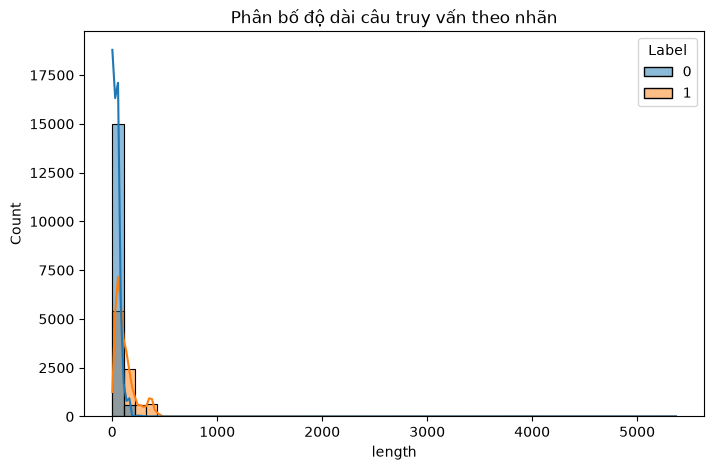

       kw_UNION     kw_OR   kw_DROP  kw_SELECT     kw_--
Label                                                   
0      0.028549  0.263027  0.002753   0.670465  0.000128
1      0.212371  0.391782  0.003406   0.878269  0.349154


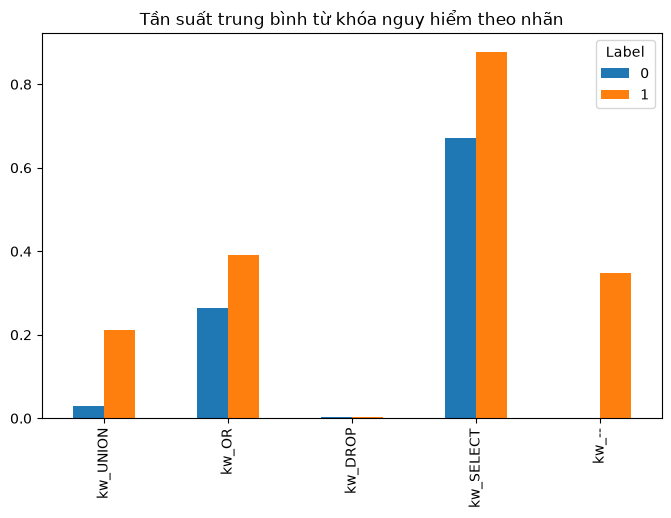

         char_'    char_;    char_=   char_--
Label                                        
0      0.661503  0.032198  0.208872  0.000128
1      1.128433  0.007251  1.205669  0.349154


In [5]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("../datasets/processed/train.csv")

train_df['length'] = train_df['Query'].str.len()

plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x='length', hue='Label', bins=50, kde=True)
plt.title("Phân bố độ dài câu truy vấn theo nhãn")
plt.savefig("../docs/images/length_distribution.png")
plt.show()

dangerous_keywords = ['UNION', 'OR', 'DROP', 'SELECT', '--']

def keyword_count(query, kw):
    return len(re.findall(re.escape(kw), query, flags=re.IGNORECASE))

for kw in dangerous_keywords:
    train_df[f'kw_{kw}'] = train_df['Query'].apply(lambda q: keyword_count(q, kw))

kw_summary = train_df.groupby('Label')[[f'kw_{kw}' for kw in dangerous_keywords]].mean()
print(kw_summary)

kw_summary.T.plot(kind='bar', figsize=(8,5))
plt.title("Tần suất trung bình từ khóa nguy hiểm theo nhãn")
plt.savefig("../docs/images/keyword_frequency.png")
plt.show()

special_chars = ["'", ";", "=", "--"]
for ch in special_chars:
    train_df[f'char_{ch}'] = train_df['Query'].apply(lambda q: q.count(ch))

char_summary = train_df.groupby('Label')[[f'char_{ch}' for ch in special_chars]].mean()
print(char_summary)